# testing RAG

A diagnostic notebook that runs the full pipeline end-to-end against a labeled dataset and reports where the RAG is weak.

### Why do we test this?

We need to test this because our RAG is not up to standard yet, and to see where it is currently lacking we want to see how it exactly is performing right now.

### How are we going to test?

End-to-end against the 15 labeled journal entries in `../ragas/eval_data/`. For each query in `queries.json` we:

1. **Retrieve** top-k chunks from the journal index.
2. **Score retrieval** by mapping chunks back to source entries and computing `Hit@k`, `Recall@k`, `MRR` against the `relevant_entries` labels.
3. **Generate** an answer with each generator model using only the retrieved context.
4. **LLM-judge** the answer on 5 quality metrics (with `expected_answer` shown to the judge as ground truth).
5. **Compare to thresholds** and print a PASS/FAIL grid.

The notebook is self-contained — it duplicates the prompts and judge plumbing from [`../ragas/eval_rag.py`](../ragas/eval_rag.py) so you can re-run everything from one place.

### What are the metrics we are going to test?

**Retrieval-only (new, fills the biggest gap)**

- **Hit@k**: did *any* chunk from a relevant entry make it into the top-k?
- **Recall@k**: what fraction of the relevant entries had at least one chunk in top-k?
- **MRR**: reciprocal rank of the first chunk from a relevant entry.

**Generation (LLM-judged, 1–5)**

1. **Context Precision**: did the retriever fetch the right, non-noisy information?
2. **Context Recall**: did the retrieved context contain enough to answer fully? (judged against `expected_answer`)
3. **Faithfulness / Groundedness**: is the generated answer based only on the provided context (no hallucination)?
4. **Answer Relevancy**: does the generated text directly address the user's question?
5. **Answer Correctness**: does the final output match the `expected_answer` in substance?

### When is it considered good enough?

Absolute per-metric thresholds (v1, recalibrate after the first full run):

| Metric | Threshold | Why |
|---|---|---|
| Hit@5 | ≥ 0.80 | Right chunk must reach the LLM 4 of 5 times. |
| Recall@5 | ≥ 0.60 | Thematic queries have multiple relevant entries; full recall is too strict. |
| MRR | ≥ 0.50 | Relevant chunk usually at position 1 or 2. |
| Faithfulness | ≥ 4.0 / 5 | Hallucination is the worst failure mode. |
| Answer Relevancy | ≥ 4.0 / 5 | Vague filler is unacceptable. |
| Context Precision | ≥ 3.5 / 5 | Some noise in retrieved chunks is tolerable. |
| Context Recall | ≥ 3.5 / 5 | New metric, calibrate after baseline. |
| Answer Correctness | ≥ 3.5 / 5 | Hardest metric — semantic match to a reference. |

### With which data are we going to test

**For now**: the 15 hand-written journal entries already in [`../ragas/eval_data/`](../ragas/eval_data/) (SOT = stress/overwhelm, SDTD = specific day-to-day, REF = deeper reflection), labeled per query in `queries.json`.

**Follow-up**: a reinforcement-learning driven synthetic 'lived life' diary — a simulated person with continuous state generates day-to-day correlated journals, giving us temporal coherence that hand-curated entries can't. The simulator would log ground-truth state alongside each entry, giving us free labels for Context Recall and Answer Correctness. Not in this notebook; flagged as the next data-quality lever.

## Scripts


## Config

In [1]:
from pathlib import Path
import json
from statistics import mean, pstdev
from typing import Any

import pandas as pd
import matplotlib.pyplot as plt
from llama_index.core import SimpleDirectoryReader, VectorStoreIndex
from llama_index.embeddings.ollama import OllamaEmbedding
from llama_index.llms.ollama import Ollama

SCRIPT_DIR      = Path(".").resolve()
EVAL_DATA_PATH  = SCRIPT_DIR.parent / "ragas" / "eval_data"
QUERIES_PATH    = SCRIPT_DIR / "queries.json"
RESULTS_PATH    = SCRIPT_DIR / "results"
OLLAMA_BASE_URL = "http://localhost:11434"
EMBED_MODEL     = "nomic-embed-text"

# Mirror eval_rag.py defaults. Avoid using the same model as both generator AND judge (self-grading bias).
MODELS_TO_TEST  = ["mistral", "llama3", "gpt-oss:20b"]
JUDGE_MODELS    = ["mistral", "llama3"]

TOP_K           = 5
MAX_QUERIES     = None     # e.g. 2 for a quick smoke test
REQUEST_TIMEOUT = 600.0

THRESHOLDS = {
    "hit@5":             0.80,
    "recall@5":          0.60,
    "mrr":               0.50,
    "faithfulness":      4.0,
    "answer_relevancy":  4.0,
    "context_precision": 3.5,
    "context_recall":    3.5,
    "answer_correctness":3.5,
}

RESULTS_PATH.mkdir(parents=True, exist_ok=True)
print("Config OK")

Config OK


## Load corpus + labels

Documents come from `eval_data/`. Each `E*-XXX.txt` filename gives us the entry ID — that's how retrieval results map back to ground-truth labels.

In [2]:
def entry_id_from_filename(name: str) -> str:
    # 'E01-SOT.txt' -> 'E01'
    return Path(name).stem.split("-")[0]

documents = SimpleDirectoryReader(str(EVAL_DATA_PATH)).load_data()
for doc in documents:
    fname = doc.metadata.get("file_name", "")
    doc.metadata["entry_id"] = entry_id_from_filename(fname)

with QUERIES_PATH.open("r", encoding="utf-8") as f:
    queries_data = json.load(f)["queries"]

if MAX_QUERIES:
    queries_data = queries_data[:MAX_QUERIES]

all_entry_ids = sorted({doc.metadata["entry_id"] for doc in documents})
label_coverage = sorted({eid for q in queries_data for eid in q["relevant_entries"]})

print(f"Loaded {len(documents)} documents -> entries: {all_entry_ids}")
print(f"Loaded {len(queries_data)} queries")
print(f"Entries referenced by queries: {label_coverage}")
missing = set(label_coverage) - set(all_entry_ids)
if missing:
    print(f"WARN: queries.json references entries that don't exist: {missing}")

Loaded 15 documents -> entries: ['E01', 'E02', 'E03', 'E04', 'E05', 'E06', 'E07', 'E08', 'E09', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15']
Loaded 13 queries
Entries referenced by queries: ['E01', 'E02', 'E03', 'E04', 'E05', 'E06', 'E07', 'E08', 'E09', 'E10', 'E11', 'E12', 'E14', 'E15']


## Build index

Same embedding + vector store as the production pipeline ([`Backend/app/services/rag.py`](../../../Backend/app/services/rag.py)). For larger corpora, persist via `StorageContext` to skip re-embedding on re-runs.

In [3]:
embed = OllamaEmbedding(model_name=EMBED_MODEL, base_url=OLLAMA_BASE_URL)
index = VectorStoreIndex.from_documents(documents, embed_model=embed)
retriever = index.as_retriever(similarity_top_k=TOP_K)
print("Index built")

c:\Users\Mathijs\Documents\code\Reflect_Audio_Journaling\Backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Index built


## Retrieval evaluation

For each query: retrieve top-k chunks, map back to source entries, score against `relevant_entries`.

- `Hit@k`: 1 if any chunk in top-k comes from a relevant entry, else 0.
- `Recall@k`: fraction of relevant entries that had a chunk in top-k.
- `MRR`: 1 / (rank of first chunk from a relevant entry).

In [4]:
def compute_retrieval_metrics(retrieved_entry_ids: list[str], relevant: list[str], k_values=(1, 3, 5)) -> dict:
    """retrieved_entry_ids is the ordered list of entry IDs for each retrieved chunk (length = top_k, may repeat)."""
    relevant_set = set(relevant)
    out: dict[str, float] = {}
    for k in k_values:
        topk_unique = set(retrieved_entry_ids[:k])
        out[f"hit@{k}"]    = float(bool(topk_unique & relevant_set))
        out[f"recall@{k}"] = len(topk_unique & relevant_set) / max(1, len(relevant_set))
    rr = 0.0
    for i, eid in enumerate(retrieved_entry_ids, start=1):
        if eid in relevant_set:
            rr = 1.0 / i
            break
    out["mrr"] = rr
    return out

def retrieve_with_entries(query: str) -> tuple[list[str], list[str], list[str]]:
    """Returns (entry_ids in retrieved order, chunk_texts, joined_context)."""
    nodes      = retriever.retrieve(query)
    entry_ids  = [n.metadata.get("entry_id", "?") for n in nodes]
    chunks     = [n.get_content() for n in nodes]
    context    = "\n\n---\n\n".join(chunks)
    return entry_ids, chunks, context

print("Retrieval helpers loaded")

Retrieval helpers loaded


In [5]:
retrieval_rows = []
for q in queries_data:
    entry_ids, chunks, context = retrieve_with_entries(q["query"])
    metrics = compute_retrieval_metrics(entry_ids, q["relevant_entries"])
    retrieval_rows.append({
        "id":               q["id"],
        "type":             q["type"],
        "query":            q["query"],
        "relevant_entries": ",".join(q["relevant_entries"]),
        "retrieved_order":  ",".join(entry_ids),
        **metrics,
    })

retrieval_df = pd.DataFrame(retrieval_rows)
print(retrieval_df[["id", "type", "hit@1", "hit@3", "hit@5", "recall@5", "mrr"]].to_string(index=False))
print("\n-- retrieval means --")
print(retrieval_df[["hit@1", "hit@3", "hit@5", "recall@5", "mrr"]].mean().round(3))

 id     type  hit@1  hit@3  hit@5  recall@5  mrr
Q01 thematic    1.0    1.0    1.0  0.600000  1.0
Q02 thematic    1.0    1.0    1.0  0.250000  1.0
Q03 thematic    0.0    1.0    1.0  0.400000  0.5
Q04 thematic    1.0    1.0    1.0  1.000000  1.0
Q05 thematic    1.0    1.0    1.0  1.000000  1.0
Q06 thematic    1.0    1.0    1.0  0.500000  1.0
Q07 thematic    0.0    1.0    1.0  0.333333  0.5
Q08   needle    0.0    0.0    0.0  0.000000  0.0
Q09   needle    1.0    1.0    1.0  1.000000  1.0
Q10   needle    1.0    1.0    1.0  1.000000  1.0
Q11   needle    1.0    1.0    1.0  1.000000  1.0
Q12   needle    1.0    1.0    1.0  1.000000  1.0
Q13   needle    1.0    1.0    1.0  1.000000  1.0

-- retrieval means --
hit@1       0.769
hit@3       0.923
hit@5       0.923
recall@5    0.699
mrr         0.846
dtype: float64


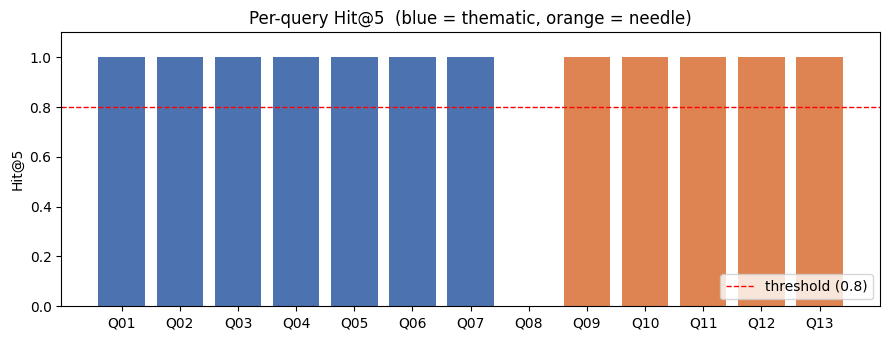

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.5))
colors = ["#4c72b0" if t == "thematic" else "#dd8452" for t in retrieval_df["type"]]
ax.bar(retrieval_df["id"], retrieval_df["hit@5"], color=colors)
ax.axhline(THRESHOLDS["hit@5"], color="red", linestyle="--", linewidth=1, label=f"threshold ({THRESHOLDS['hit@5']})")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Hit@5")
ax.set_title("Per-query Hit@5  (blue = thematic, orange = needle)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Generation evaluation

For each query × generator model: generate an answer from the retrieved context, then judge it on 5 metrics. The judge sees `expected_answer` as ground truth so it can score Context Recall and Answer Correctness.

In [7]:
ANSWER_PROMPT = """You are an evidence-grounded reflection assistant.

Answer the user's question using only the retrieved journal context.
If context is insufficient, say what is missing instead of inventing details.

Question:
{query}

Retrieved context:
{context}

Answer:"""

JUDGE_PROMPT = """You are grading a RAG answer. Be strict and unsparing.
Respond only with valid JSON, no extra text.

Question:
{query}

Retrieved context:
{context}

Model answer:
{answer}

Reference answer (ground truth):
{expected_answer}

Score each 1-5:
- faithfulness: every claim in the model answer is supported by the retrieved context; penalize invented details hard.
- answer_relevancy: directly addresses the question without vague filler.
- context_precision: the retrieved context is on-point, not generic statements disconnected from evidence.
- context_recall: the retrieved context contains enough information to fully answer the question, judged against the reference answer.
- answer_correctness: the model answer matches the reference answer in substance.

{{"faithfulness": N, "answer_relevancy": N, "context_precision": N, "context_recall": N, "answer_correctness": N, "reason": "one sentence"}}"""

print("Prompts loaded")

Prompts loaded


In [8]:
METRICS = (
    "faithfulness",
    "answer_relevancy",
    "context_precision",
    "context_recall",
    "answer_correctness",
)

def build_llm(model_name: str) -> Ollama:
    extra = {"think": False} if "qwen" in model_name.lower() else {}
    return Ollama(model=model_name, base_url=OLLAMA_BASE_URL,
                  request_timeout=REQUEST_TIMEOUT, additional_kwargs=extra)

def extract_json_dict(raw: str) -> dict:
    text = raw.strip()
    if text.startswith("```"):
        text = text.strip("`")
        if text.startswith("json"):
            text = text[4:]
        text = text.strip()
    try:
        p = json.loads(text)
        return p if isinstance(p, dict) else {}
    except json.JSONDecodeError:
        s, e = text.find("{"), text.rfind("}") + 1
        if s == -1 or e <= s:
            return {}
        try:
            p = json.loads(text[s:e])
            return p if isinstance(p, dict) else {}
        except json.JSONDecodeError:
            return {}

def to_score(v) -> int | None:
    try:
        s = int(v)
    except (TypeError, ValueError):
        return None
    return max(1, min(5, s))

def generate_answer(llm, query: str, context: str) -> str:
    return str(llm.complete(ANSWER_PROMPT.format(query=query, context=context))).strip()

def judge_answer(judge_llm, query: str, context: str, answer: str, expected_answer: str) -> dict:
    raw = str(judge_llm.complete(JUDGE_PROMPT.format(
        query=query, context=context, answer=answer, expected_answer=expected_answer))).strip()
    return extract_json_dict(raw)

def aggregate_judgements(payloads: dict) -> dict:
    per: dict[str, dict] = {}
    reasons: list[str] = []
    valid = 0
    for jname, payload in payloads.items():
        row = {m: to_score(payload.get(m)) for m in METRICS}
        per[jname] = row
        if any(v is not None for v in row.values()):
            valid += 1
        r = payload.get("reason", "")
        if isinstance(r, str) and r.strip():
            reasons.append(f"{jname}: {r.strip()}")
    agg: dict = {}
    for m in METRICS:
        vals = [row[m] for row in per.values() if row[m] is not None]
        agg[m] = round(mean(vals), 3) if vals else None
        agg[f"{m}_judge_std"] = (None if not vals else 0.0 if len(vals) == 1
                                 else round(pstdev(vals), 3))
    n = max(1, len(payloads))
    agg["judge_valid_count"] = valid
    agg["judge_valid_rate"]  = round(valid / n, 3)
    agg["judge_reasons"]     = " | ".join(reasons)
    return agg

print("Generation helpers loaded")

Generation helpers loaded


In [9]:
judge_llms = {j: build_llm(j) for j in JUDGE_MODELS}
print(f"Queries: {len(queries_data)}  |  Generators: {MODELS_TO_TEST}  |  Judges: {list(judge_llms)}")

gen_rows = []
for model_name in MODELS_TO_TEST:
    print(f"\n-- {model_name} --")
    gen_llm = build_llm(model_name)
    for q in queries_data:
        entry_ids, chunks, context = retrieve_with_entries(q["query"])
        answer  = generate_answer(gen_llm, q["query"], context)
        payloads = {jname: judge_answer(jllm, q["query"], context, answer, q["expected_answer"])
                    for jname, jllm in judge_llms.items()}
        agg = aggregate_judgements(payloads)
        print(f"  {q['id']}: {q['query'][:60]}...")
        print(f"       A: {answer[:90]}{'...' if len(answer) > 90 else ''}")
        gen_rows.append({
            "model":            model_name,
            "id":               q["id"],
            "type":             q["type"],
            "query":            q["query"],
            "retrieved_order": ",".join(entry_ids),
            "answer":           answer,
            **agg,
        })

generation_df = pd.DataFrame(gen_rows)
print("\nDone.")

Queries: 13  |  Generators: ['mistral', 'llama3', 'gpt-oss:20b']  |  Judges: ['mistral', 'llama3']

-- mistral --
  Q01: What recurring patterns appear in how I handle work stress?...
       A: The user appears to struggle with handling work stress by working beyond reasonable hours,...
  Q02: What does my relationship with productivity look like?...
       A: Based on the provided journal context, it appears that your relationship with productivity...
  Q03: How do I talk about my relationships with other people?...
       A: The journal context suggests a personal reflection on being more aware of the good aspects...
  Q04: What themes come up when I am having a low energy day?...
       A: The themes that come up when the user is having a low energy day include feelings of letha...
  Q05: What am I avoiding or procrastinating on?...
       A: The user appears to be avoiding or procrastinating on reflecting critically on feedback th...
  Q06: Where do I sound conflicted between value

## Combined report & threshold check

Per-model aggregate across all metrics, then PASS/FAIL vs. `THRESHOLDS`.

In [10]:
retrieval_means = retrieval_df[["hit@5", "recall@5", "mrr"]].mean()

gen_summary = (
    generation_df.groupby("model")
    .agg(
        samples=("answer", "count"),
        faithfulness=("faithfulness", "mean"),
        answer_relevancy=("answer_relevancy", "mean"),
        context_precision=("context_precision", "mean"),
        context_recall=("context_recall", "mean"),
        answer_correctness=("answer_correctness", "mean"),
        judge_valid_rate=("judge_valid_rate", "mean"),
    )
    .round(3)
)

# Retrieval is model-independent (same retriever for all generators) so add as constant columns.
for k, v in retrieval_means.items():
    gen_summary[k] = round(v, 3)

summary_df = gen_summary[[
    "samples",
    "hit@5", "recall@5", "mrr",
    "faithfulness", "answer_relevancy", "context_precision",
    "context_recall", "answer_correctness",
    "judge_valid_rate",
]].sort_values(["answer_correctness", "faithfulness"], ascending=False)

print(summary_df)

             samples  hit@5  recall@5    mrr  faithfulness  answer_relevancy  \
model                                                                          
gpt-oss:20b       13  0.923     0.699  0.846         1.792             2.458   
mistral           13  0.923     0.699  0.846         1.962             2.385   
llama3            13  0.923     0.699  0.846         1.667             2.167   

             context_precision  context_recall  answer_correctness  \
model                                                                
gpt-oss:20b              2.250           2.083               1.708   
mistral                  2.346           1.923               1.423   
llama3                   2.417           1.708               1.292   

             judge_valid_rate  
model                          
gpt-oss:20b             0.731  
mistral                 0.885  
llama3                  0.769  


In [11]:
def threshold_grid(summary: pd.DataFrame, thresholds: dict) -> pd.DataFrame:
    rows = []
    for model, row in summary.iterrows():
        verdict = {}
        for metric, cutoff in thresholds.items():
            value = row.get(metric)
            if value is None or (isinstance(value, float) and pd.isna(value)):
                verdict[metric] = "n/a"
            else:
                verdict[metric] = f"PASS ({value:.2f})" if value >= cutoff else f"FAIL ({value:.2f})"
        verdict["_overall"] = "PASS" if all(v.startswith("PASS") for v in verdict.values() if v != "n/a") else "FAIL"
        verdict["_model"] = model
        rows.append(verdict)
    grid = pd.DataFrame(rows).set_index("_model")
    return grid

grid = threshold_grid(summary_df, THRESHOLDS)
print(grid.to_string())

retrieval_path = RESULTS_PATH / "retrieval.csv"
generation_path = RESULTS_PATH / "generation.csv"
summary_path = RESULTS_PATH / "summary.csv"
grid_path = RESULTS_PATH / "threshold_grid.csv"

retrieval_df.to_csv(retrieval_path, index=False)
generation_df.to_csv(generation_path, index=False)
summary_df.to_csv(summary_path)
grid.to_csv(grid_path)

print(f"\nSaved -> {retrieval_path}")
print(f"Saved -> {generation_path}")
print(f"Saved -> {summary_path}")
print(f"Saved -> {grid_path}")

                   hit@5     recall@5          mrr faithfulness answer_relevancy context_precision context_recall answer_correctness _overall
_model                                                                                                                                       
gpt-oss:20b  PASS (0.92)  PASS (0.70)  PASS (0.85)  FAIL (1.79)      FAIL (2.46)       FAIL (2.25)    FAIL (2.08)        FAIL (1.71)     FAIL
mistral      PASS (0.92)  PASS (0.70)  PASS (0.85)  FAIL (1.96)      FAIL (2.38)       FAIL (2.35)    FAIL (1.92)        FAIL (1.42)     FAIL
llama3       PASS (0.92)  PASS (0.70)  PASS (0.85)  FAIL (1.67)      FAIL (2.17)       FAIL (2.42)    FAIL (1.71)        FAIL (1.29)     FAIL

Saved -> C:\Users\Mathijs\Documents\code\Reflect_Audio_Journaling\Research\RAG\tests\results\retrieval.csv
Saved -> C:\Users\Mathijs\Documents\code\Reflect_Audio_Journaling\Research\RAG\tests\results\generation.csv
Saved -> C:\Users\Mathijs\Documents\code\Reflect_Audio_Journaling\Research